In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive/')


#move to working directory:
#%cd /content/drive/My Drive/Colab Notebooks/ #MSG
%cd /content/drive/My Drive/Lucy Colab Notebooks

Mounted at /content/drive/
/content/drive/My Drive/Lucy Colab Notebooks


In [ ]:
!ls "./"

 160614Lau_D16-5510_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi_221232939_ref_NC_011916.1_.wig
 160614Lau_D16-5512_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi_221232939_ref_NC_011916.1_.wig
 160614Lau_D16-5513_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi_221232939_ref_NC_011916.1_.wig
'160614Lau_D16-5514_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi|221232939|ref|NC_011916.1|.wig'
 7B-TSSstart.pdf
 7C-TESstop.pdf
 7D-chip.pdf
 9G-AT_nearest-tss_noDuplicates.pdf
 9G_AT-only_withDuplicates.pdf
 9G-SC_nearestTSS_no-Duplicates.pdf
 9G-SC-only_withDuplicates.pdf
 allPearsons
 caulobacter_background.txt
 caulobacter.fasta
'CHIP distance to nearest TES_LIN.pdf'
 Code4Figs
'Copy of Figure6AD_rep-images.ipynb'
'Copy of GapR-Promoters-6-HighTxnGene_withstats.ipynb'
 data
'distance from TSS to nearest CHIP_LIN.pdf'
 distance_to_nearest_tsstart_boxplot_LIN.pdf
'distance to nearest TSSTART_LIN.pdf'
 distance_to_nearest_tsstop_boxplot_LIN.pdf
 distance_to_nea

# Installations

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.2 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.signal as signal
from scipy import cluster
from Bio import SeqIO
from Bio.Seq import Seq, MutableSeq
import urllib.request
%matplotlib inline

sns.set_style('white')
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15

In [ ]:

# 1. Setup the directory
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)

# 2. Define your NCBI FTP links (Replace these with your actual NCBI links)
datasets = {
    "chip_1": "https://ftp.ncbi.nlm.nih.gov/.../chip_sample1.fastq.gz",
    "chip_2": "https://ftp.ncbi.nlm.nih.gov/.../chip_sample2.fastq.gz",
    "chip_3": "https://ftp.ncbi.nlm.nih.gov/.../chip_sample3.fastq.gz",
    "rna_1": "https://ftp.ncbi.nlm.nih.gov/.../rna_sample1.fastq.gz",
    "rna_2": "https://ftp.ncbi.nlm.nih.gov/.../rna_sample2.fastq.gz"
}

# 3. The Download Loop
for name, url in datasets.items():
    filename = os.path.join(data_dir, f"{name}.fastq.gz")

    if not os.path.exists(filename):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{name} already exists. Skipping.")

print("All datasets ready for analysis!")

# functions

In [ ]:
#functions for loading and smoothing ChIP-seq and RNA-seq

def gaussian_smooth(data_array, index_step, sigma):
    mu = 0
    bins = np.arange(-4*sigma, 4*sigma, index_step, dtype=np.float32)
    gaussian = index_step*1/(sigma * np.sqrt(2 * np.pi))*np.exp( - (bins - mu)**2 / (2 * sigma**2) )
    return signal.convolve(data_array,gaussian,mode='same')


def initialize_rpm(data,index_step,length):
  """uses gaussian smooth to normalize ChIP array"""
  smoothed_data = np.zeros([1, length], dtype=np.float32)
  smoothed_data[0][:] = gaussian_smooth(data[0],index_step,5*index_step)
  rpm = np.zeros([1, length])
  normalization_factor=float(sum(smoothed_data[0][:]))/float(1000000)
  print(normalization_factor)
  for i in range(0,length):
      rpm[0][i]=float(smoothed_data[0][i])/normalization_factor

  return rpm

def loading_chip_data(name):
  """uses initialize_rpm to load and smooth ChIP-seq files"""
  coordinate=np.loadtxt(name, dtype=np.int32, delimiter='\t', skiprows=2)
  chip_data=np.zeros([1,len(caulobacterfasta.seq)])
  ind=coordinate[:,0]<len(caulobacterfasta.seq)
  chip_data[0][coordinate[ind,0]-1]=coordinate[ind,1]
  chip_rpm=initialize_rpm(chip_data, 10, len(caulobacterfasta.seq))
  return chip_rpm

def load_rnaseq_data(name):
  """Loads RNA-seq data from a tab-delimited file into a pandas DataFrame."""
  rnaseq_data = pd.read_csv(name, sep='\t', index_col = None, skiprows=2, names=['position', 'value'])
  return rnaseq_data

In [ ]:
#Building caulobacter genome as "transcription units" from RNA-seq data
class Genome:
    def __init__(self, genome_list,genome_annotation, start, end, strand, length):
        self.name=genome_list #list with every gene CCNA_##
        self.annotation=genome_annotation
        self.start=start
        self.end=end
        self.strand=strand
        self.length=length

def loading_fasta_gbk(file_name,typeoffile):
    loaded=SeqIO.read(file_name, typeoffile)
    return loaded


def reading_gbk_new(gbk_file, features_to_extract):
    """function that will load from the gbk file: the start, end, strand and length of gene as well as the name and annotated name/function.
    Returns one array and 2 lists """

    genome_gene=[]
    genome_gene_name=[]

    genome_start=[]
    genome_end=[]
    genome_strand=[]
    genome_length=[]
    print(len(features_to_extract))
    for i in range(0,len(gbk_file.features)):
        isfeature=False
        for j in range(len(features_to_extract)):
            if gbk_file.features[i].type == features_to_extract[j]:
                isfeature=True

        if isfeature==True:

            genome_gene.append(gbk_file.features[i].qualifiers['locus_tag'][0])

            if 'product' in gbk_file.features[i].qualifiers:
                genome_gene_name.append(gbk_file.features[i].qualifiers['product'][0])
            else:
                genome_gene_name.append('NA')

            if gbk_file.features[i].location.strand < 0 :
                genome_start.append(gbk_file.features[i].location.end)
                genome_end.append(gbk_file.features[i].location.start)
                genome_strand.append(-1)
                genome_length.append(abs(gbk_file.features[i].location.end-gbk_file.features[i].location.start)+1)
            else:
                genome_start.append(gbk_file.features[i].location.start)
                genome_end.append(gbk_file.features[i].location.end)
                genome_strand.append(1)
                genome_length.append(abs(gbk_file.features[i].location.end-gbk_file.features[i].location.start)+1)

    genome = Genome(genome_gene,genome_gene_name,genome_start,genome_end,genome_strand,genome_length)

    return genome



In [ ]:
caulobactergbk=loading_fasta_gbk('./data/NC_011916.gbk','genbank')
caulobacterfasta=loading_fasta_gbk('./data/NC_011916.fna','fasta')
genome=reading_gbk_new(caulobactergbk,['CDS','tRNA','rRNA','ncRNA'])
print(len(caulobactergbk))

4
4042929


In [ ]:
##Genome representation
#puts a 1 where there is a gene

genome_gene_representation = np.zeros([1,len(caulobacterfasta.seq)])

for genes in [genome]:
    for i in range (0, len(genes.annotation)):
        if genes.strand[i]== +1:

            for j in range(0, genes.length[i]-1):
                genome_gene_representation[0][genes.start[i]+j]=10
        else:
            for j in range(0,genes.length[i]-1):
                genome_gene_representation[0][genes.end[i]+j]=-10

In [ ]:
#@title loading ChIP data from GSE100657, Guo and Haakonsen 2018

#GapR - wild type
chip_356=loading_chip_data('/content/drive/MyDrive/Lucy Colab Notebooks/GitHub/data/160614Lau_D16-5510_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi_221232939_ref_NC_011916.1_.wig')
#GapR-3xFLAG RFI treated
chip_rif=loading_chip_data('/content/drive/MyDrive/Lucy Colab Notebooks/GitHub/data/160614Lau_D16-5513_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi_221232939_ref_NC_011916.1_.wig')
#NOTAG version
notag_chip=loading_chip_data('/content/drive/MyDrive/Lucy Colab Notebooks/GitHub/data/160614Lau_D16-5512_CcreNA1000_bestmap.sammacs.samout_treat_afterfiting_gi_221232939_ref_NC_011916.1_.wig')

#normalize GapR-3XFLAG ChIP to the untagged version
diane = pd.DataFrame(notag_chip[0])
diane['356'] = chip_356[0]
diane['rif'] = chip_rif[0]
diane.columns = ['wt','gapR','gapR-rif']

gapR_rif_norm = diane['gapR-rif'] - diane['wt']
gapR_wt_norm = diane['gapR'] - diane['wt']

1999.826304
2000.08896
1998.060672


In [ ]:
# @title calculating ATcontent using a sliding window
def ATcontent_caulo(start, end):
    sequence_slice = caulobacterfasta.seq[start:end]
    gc_count = sequence_slice.count('G') + sequence_slice.count('C')
    total_length = len(sequence_slice)
    if total_length == 0:
        return 0
    gc_content_percentage = (gc_count / total_length) * 100
    content = 100 - gc_content_percentage
    return content

# create a size adjustable sliding window to record AT content
def sliding_window_caulo(window_length):
    sliding_array=np.zeros([1,len(caulobacterfasta.seq)])
    for i in range(int(window_length/2), len(caulobacterfasta.seq)-int(window_length/2)):
        start=i-int(window_length/2)
        end=i+int(window_length/2)
        sliding_array[0][i]=ATcontent_caulo(start, end)
    return sliding_array

#make a 300bp sliding window across genome
sliding_300_caulo=sliding_window_caulo(300)

#Figure 8A/S2A, 8E/S2D : ChIP-seq vs. RNA-seq vs. genome position

In [ ]:
#Load data from GapR-3xFLAG RNA-seq (GSM2690554)
W356_RNArev_df = load_rnaseq_data('./data/D16-4815-1939G_align_out_norm_rv.wig')
W356_RNAfor_df = load_rnaseq_data('./data/D16-4815-1939G_align_out_norm_fw.wig')

# AT corr (allow shape (1, N))
at_arr = np.asarray(sliding_300_caulo)
if at_arr.ndim == 2 and at_arr.shape[0] == 1:
    at_arr = at_arr[0]

wt_arr  = np.asarray(gapR_wt_norm)
rif_arr = np.asarray(gapR_rif_norm)
WT_for  = np.asarray(W356_RNAfor_df['value'])
WT_rev  = np.asarray(W356_RNArev_df['value'])

# Gene orientation (allow shape (1, N))
gene_track = np.asarray(genome_gene_representation)
if gene_track.ndim == 2:
    gene_track = gene_track[0]

#trim lengths
common_len = min(map(len, [at_arr, wt_arr, rif_arr, WT_for, WT_rev, gene_track]))
at_arr, wt_arr, rif_arr, WT_for, WT_rev, gene_track = \
    at_arr[:common_len], wt_arr[:common_len], rif_arr[:common_len], WT_for[:common_len], WT_rev[:common_len], gene_track[:common_len]


###Figure 8A - AT dependent binding example

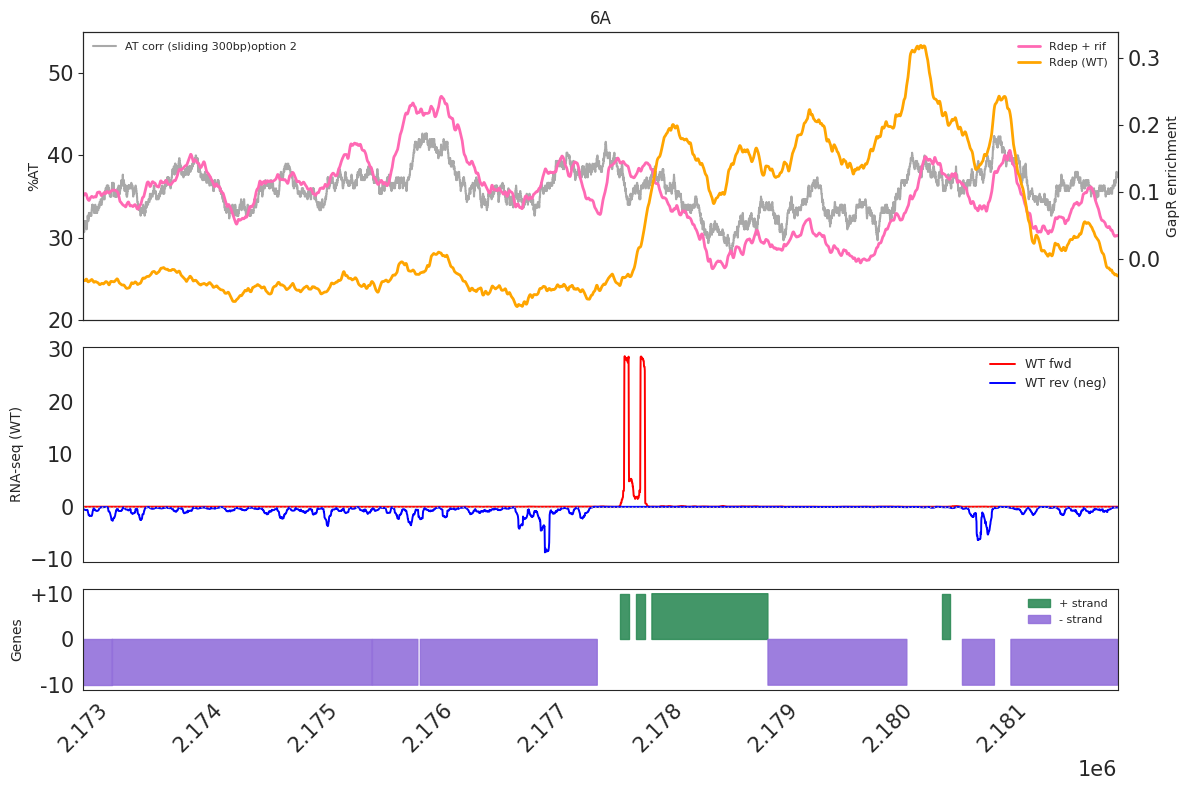

In [ ]:
# window
s, e   = 2173000, 2182000

N = len(at_arr)
startplot = max(0, int(s))
endplot   = min(N, int(e))

x_step = np.arange(startplot, endplot)

# making the figure 3 boxes, setting up axis
fig, (ax_top, ax_rna, ax_genes) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.5, 0.7]}
)

# 1) plotting AT + ChIP on twin axis
ax2 = ax_top.twinx()
ax_top.plot(x_step, at_arr[startplot:endplot], color='darkgrey', label='AT corr (sliding 300bp)option 2', zorder=1)
ax2.plot(x_step, rif_arr[startplot:endplot], color='hotpink', linewidth=2.0, label='Rdep + rif')
ax2.plot(x_step, wt_arr[startplot:endplot:],  color='orange',  linewidth=2.0, label='Rdep (WT)')
ax_top.set_ylabel('%AT')
ax2.set_ylabel('GapR enrichment')
ax_top.legend(loc='upper left', fontsize=8, frameon=False)
ax2.legend(loc='upper right', fontsize=8, frameon=False)
ax_top.set_title(f'9A')
ax_top.set_xlim(startplot, endplot - 1)
ax_top.set_ylim(20, 55) # Manually set AT content y-axis limits

# 2) untreated Caulobacter RNA-seq
ax_rna.plot(x_step,  WT_for[startplot:endplot],  color='red',  linewidth=1.4, label='WT fwd')
ax_rna.plot(x_step, -WT_rev[startplot:endplot], color='blue', linewidth=1.4, label='WT rev (neg)')
ax_rna.axhline(0, color='0.7', lw=1, ls=':')
ax_rna.set_ylabel('RNA-seq (WT)')
ax_rna.legend(loc='upper right', fontsize=9, frameon=False)

# 3) Gene orientation
g = gene_track[startplot:endplot]
pos_mask = g > 0
neg_mask = g < 0

# filled blocks for strands
ax_genes.fill_between(x_step, 0, g, where=pos_mask, step='pre', color='seagreen',    alpha=0.9, label='+ strand')
ax_genes.fill_between(x_step, 0, g, where=neg_mask, step='pre', color='mediumpurple', alpha=0.9, label='- strand')

ax_genes.set_ylim(-11, 11)
ax_genes.set_yticks([-10, 0, 10])
ax_genes.set_yticklabels(['-10', '0', '+10'])
ax_genes.set_ylabel('Genes')
ax_genes.legend(loc='upper right', fontsize=8, frameon=False)
ax_genes.tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('8A.pdf')
plt.show()

### Figure S6A: more AT-dependent binding

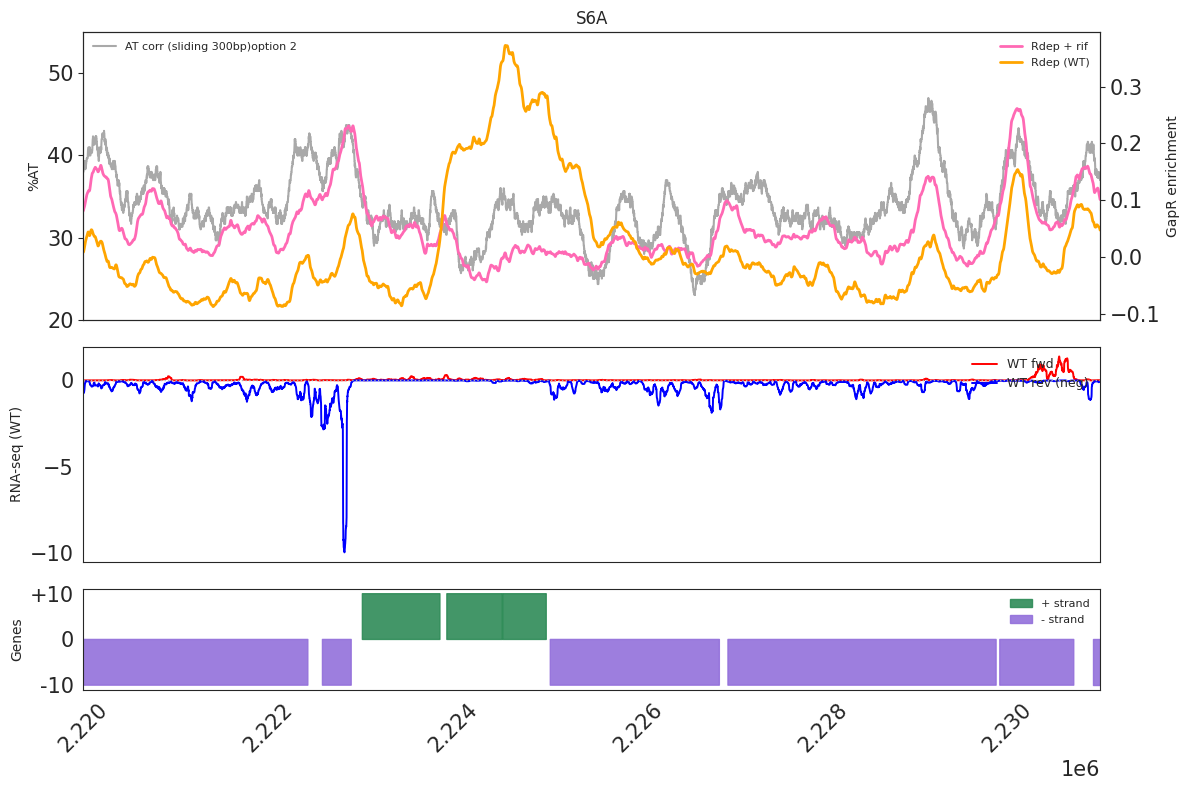

In [ ]:
# window
s, e   = 2220000, 2231000

N = len(at_arr)
startplot = max(0, int(s))
endplot   = min(N, int(e))

x_step = np.arange(startplot, endplot)

# making the figure 3 boxes, setting up axis
fig, (ax_top, ax_rna, ax_genes) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.5, 0.7]}
)

# 1) plotting AT + ChIP on twin axis
ax2 = ax_top.twinx()
ax_top.plot(x_step, at_arr[startplot:endplot], color='darkgrey', label='AT corr (sliding 300bp)option 2', zorder=1)
ax2.plot(x_step, rif_arr[startplot:endplot], color='hotpink', linewidth=2.0, label='Rdep + rif')
ax2.plot(x_step, wt_arr[startplot:endplot:],  color='orange',  linewidth=2.0, label='Rdep (WT)')
ax_top.set_ylabel('%AT')
ax2.set_ylabel('GapR enrichment')
ax_top.legend(loc='upper left', fontsize=8, frameon=False)
ax2.legend(loc='upper right', fontsize=8, frameon=False)
ax_top.set_title(f'S6A')
ax_top.set_xlim(startplot, endplot - 1)
ax_top.set_ylim(20, 55) # Manually set AT content y-axis limits

# 2) untreated Caulobacter RNA-seq (rev negated)
ax_rna.plot(x_step,  WT_for[startplot:endplot],  color='red',  linewidth=1.4, label='WT fwd')
ax_rna.plot(x_step, -WT_rev[startplot:endplot], color='blue', linewidth=1.4, label='WT rev (neg)')
ax_rna.axhline(0, color='0.7', lw=1, ls=':')
ax_rna.set_ylabel('RNA-seq (WT)')
ax_rna.legend(loc='upper right', fontsize=9, frameon=False)

# 3) Gene orientation
g = gene_track[startplot:endplot]
pos_mask = g > 0
neg_mask = g < 0

# filled blocks for strands
ax_genes.fill_between(x_step, 0, g, where=pos_mask, step='pre', color='seagreen',    alpha=0.9, label='+ strand')
ax_genes.fill_between(x_step, 0, g, where=neg_mask, step='pre', color='mediumpurple', alpha=0.9, label='- strand')

ax_genes.set_ylim(-11, 11)
ax_genes.set_yticks([-10, 0, 10])
ax_genes.set_yticklabels(['-10', '0', '+10'])
ax_genes.set_ylabel('Genes')
ax_genes.legend(loc='upper right', fontsize=8, frameon=False)
ax_genes.tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('S6A.pdf')
plt.show()

###Figure 8E - supercoiling example

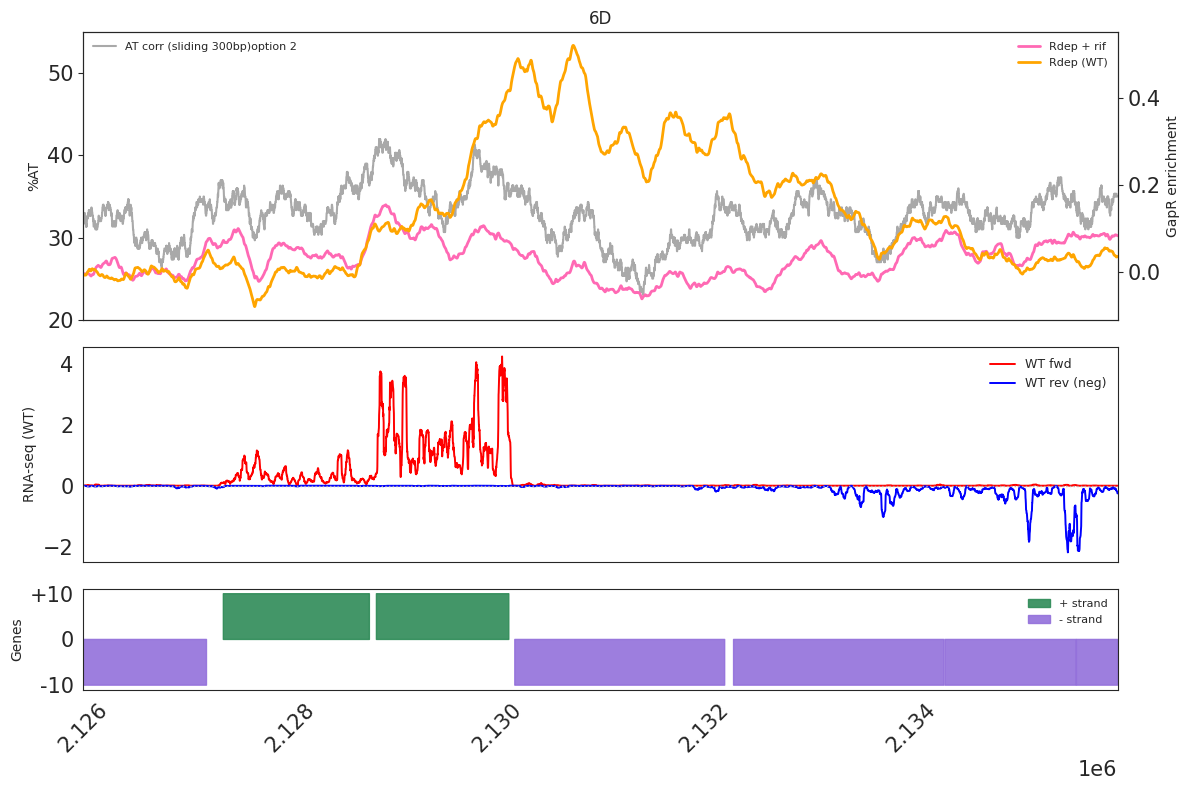

In [ ]:
#window
s, e   = 2126000, 2136000

N = len(at_arr)
startplot = max(0, int(s))
endplot   = min(N, int(e))

x_step = np.arange(startplot, endplot)

# making the figure 3 boxes, setting up axis
fig, (ax_top, ax_rna, ax_genes) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.5, 0.7]}
)

# 1) plotting AT + ChIP on twin axis
ax2 = ax_top.twinx()
ax_top.plot(x_step, at_arr[startplot:endplot], color='darkgrey', label='AT corr (sliding 300bp)option 2', zorder=1)
ax2.plot(x_step, rif_arr[startplot:endplot], color='hotpink', linewidth=2.0, label='Rdep + rif')
ax2.plot(x_step, wt_arr[startplot:endplot:],  color='orange',  linewidth=2.0, label='Rdep (WT)')
ax_top.set_ylabel('%AT')
ax2.set_ylabel('GapR enrichment')
ax_top.legend(loc='upper left', fontsize=8, frameon=False)
ax2.legend(loc='upper right', fontsize=8, frameon=False)
ax_top.set_title(f'6D')
ax_top.set_xlim(startplot, endplot - 1)
ax_top.set_ylim(20, 55) # Manually set AT content y-axis limits

# 2) untreated Caulobacter RNA-seq (rev negated)
ax_rna.plot(x_step,  WT_for[startplot:endplot],  color='red',  linewidth=1.4, label='WT fwd')
ax_rna.plot(x_step, -WT_rev[startplot:endplot], color='blue', linewidth=1.4, label='WT rev (neg)')
ax_rna.axhline(0, color='0.7', lw=1, ls=':')
ax_rna.set_ylabel('RNA-seq (WT)')
ax_rna.legend(loc='upper right', fontsize=9, frameon=False)

# 3) Gene orientation
g = gene_track[startplot:endplot]
pos_mask = g > 0
neg_mask = g < 0

# filled blocks for strands
ax_genes.fill_between(x_step, 0, g, where=pos_mask, step='pre', color='seagreen',    alpha=0.9, label='+ strand')
ax_genes.fill_between(x_step, 0, g, where=neg_mask, step='pre', color='mediumpurple', alpha=0.9, label='- strand')

ax_genes.set_ylim(-11, 11)
ax_genes.set_yticks([-10, 0, 10])
ax_genes.set_yticklabels(['-10', '0', '+10'])
ax_genes.set_ylabel('Genes')
ax_genes.legend(loc='upper right', fontsize=8, frameon=False)
ax_genes.tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('8E.pdf')
plt.show()

### Figure S2D: supercoiling deenrichment

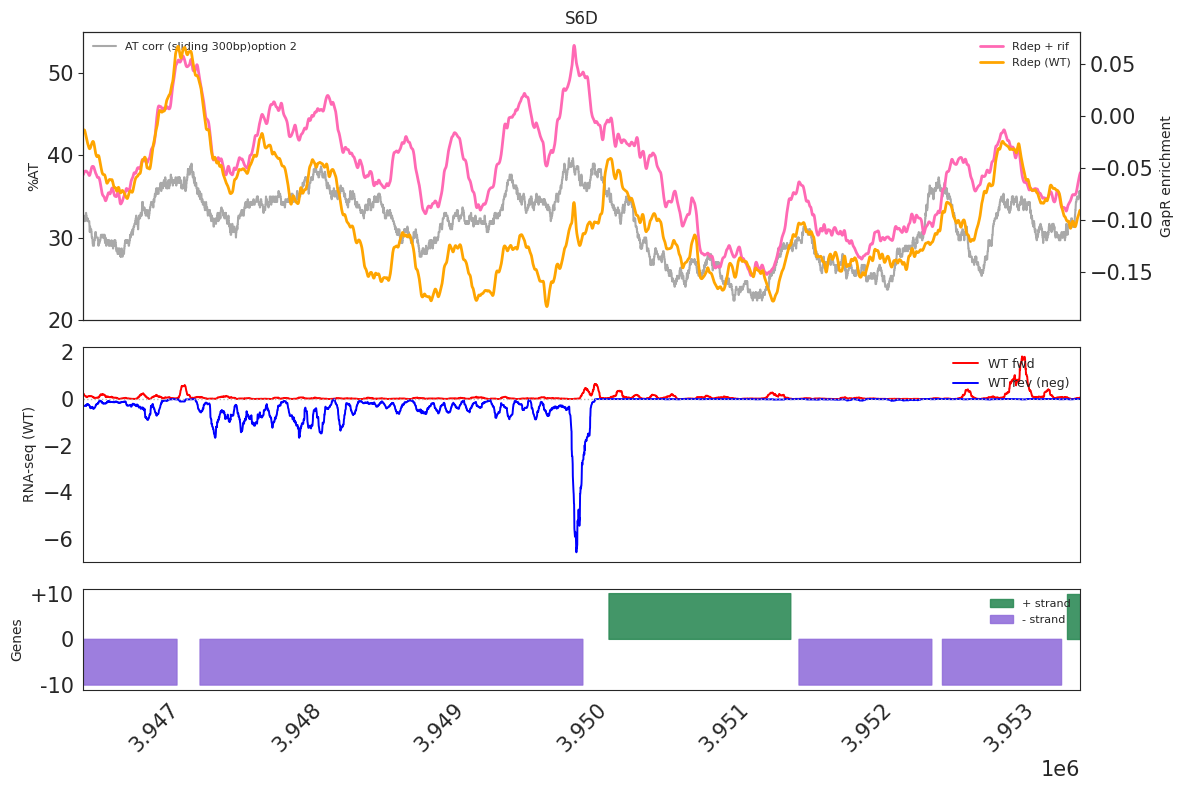

In [ ]:
#window
s, e   = 3946500, 3953500

N = len(at_arr)
startplot = max(0, int(s))
endplot   = min(N, int(e))

x_step = np.arange(startplot, endplot)

# making the figure 3 boxes, setting up axis
fig, (ax_top, ax_rna, ax_genes) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.5, 0.7]}
)

# 1) plotting AT + ChIP on twin axis
ax2 = ax_top.twinx()
ax_top.plot(x_step, at_arr[startplot:endplot], color='darkgrey', label='AT corr (sliding 300bp)option 2', zorder=1)
ax2.plot(x_step, rif_arr[startplot:endplot], color='hotpink', linewidth=2.0, label='Rdep + rif')
ax2.plot(x_step, wt_arr[startplot:endplot:],  color='orange',  linewidth=2.0, label='Rdep (WT)')
ax_top.set_ylabel('%AT')
ax2.set_ylabel('GapR enrichment')
ax_top.legend(loc='upper left', fontsize=8, frameon=False)
ax2.legend(loc='upper right', fontsize=8, frameon=False)
ax_top.set_title(f'S6D')
ax_top.set_xlim(startplot, endplot - 1)
ax_top.set_ylim(20, 55) # Manually set AT content y-axis limits

# 2) untreated Caulobacter RNA-seq (rev negated)
ax_rna.plot(x_step,  WT_for[startplot:endplot],  color='red',  linewidth=1.4, label='WT fwd')
ax_rna.plot(x_step, -WT_rev[startplot:endplot], color='blue', linewidth=1.4, label='WT rev (neg)')
ax_rna.axhline(0, color='0.7', lw=1, ls=':')
ax_rna.set_ylabel('RNA-seq (WT)')
ax_rna.legend(loc='upper right', fontsize=9, frameon=False)

# 3) Gene orientation
g = gene_track[startplot:endplot]
pos_mask = g > 0
neg_mask = g < 0

# filled blocks for strands
ax_genes.fill_between(x_step, 0, g, where=pos_mask, step='pre', color='seagreen',    alpha=0.9, label='+ strand')
ax_genes.fill_between(x_step, 0, g, where=neg_mask, step='pre', color='mediumpurple', alpha=0.9, label='- strand')

ax_genes.set_ylim(-11, 11)
ax_genes.set_yticks([-10, 0, 10])
ax_genes.set_yticklabels(['-10', '0', '+10'])
ax_genes.set_ylabel('Genes')
ax_genes.legend(loc='upper right', fontsize=8, frameon=False)
ax_genes.tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('S2D.pdf')
plt.show()

#Figure 8B: Pearson Correlations between AT-content and ChIP signal


In [ ]:
def sliding_window_correlation(data1, data2, window_size):
    """
    Calculates the Pearson correlation coefficient in sliding windows.
    Returns a pandas series containing the correlation coefficients for each window.
    """
    correlations = []
    # Ensure both datasets are aligned and have the same length for slicing
    min_length = min(len(data1), len(data2))
    data1_truncated = data1.iloc[:min_length].squeeze()
    data2_truncated = data2.iloc[:min_length].squeeze()


    for i in range(0, min_length - window_size + 1):
        window1 = data1_truncated.iloc[i : i + window_size]
        window2 = data2_truncated.iloc[i : i + window_size]

        correlation = window1.corr(window2, method='pearson')
        correlations.append(correlation)

    correlation_series = pd.Series(correlations, index=range(0, min_length - window_size + 1))

    return correlation_series


In [ ]:
# Define window size for pearson correlation
window_size = 10000

# Calculate sliding window correlation between at_content_1bp and gapR_rif_norm/gapR_wt_norm
# Convert sliding_300 to a pandas Series before passing to the function

if os.path.exists('./data/wt_sliding_corr.txt'):
  wt_sliding_corr = pd.read_csv('./data/wt_sliding_corr.txt', sep='\t', header=None,index_col=0)

else:
  print('running wt correlation')
  wt_sliding_corr = sliding_window_correlation(pd.Series(sliding_300_caulo[0]), gapR_wt_norm, window_size)
  wt_sliding_corr.to_csv('./data/wt_sliding_corr.txt', sep='\t')


if os.path.exists('./data/rif_sliding_corr.txt'):
  rif_sliding_corr = pd.read_csv('./data/rif_sliding_corr.txt', sep='\t', header=None,index_col=0)

else:
  print('running rif correlation')
  rif_sliding_corr = sliding_window_correlation(pd.Series(sliding_300_caulo[0]), gapR_rif_norm, window_size)
  rif_sliding_corr.to_csv('./data/rif_sliding_corr.txt', sep='\t')


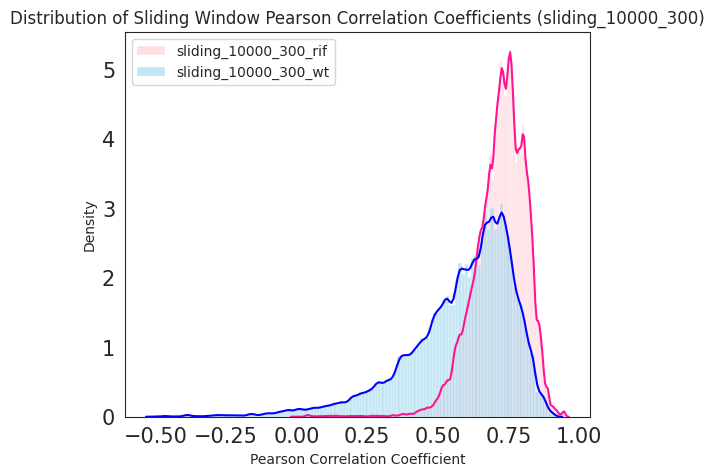

Mean Pearson's R for Rif group: 0.7209
Mean Pearson's R for WT group: 0.5813


In [ ]:
# Plot histograms
plt.figure(figsize=(6, 5))
sns.histplot(rif_sliding_corr[1], stat='density', color='pink', label='sliding_10000_300_rif',
             alpha=0.5, common_norm=False, bins = 125)
sns.histplot(wt_sliding_corr[1], stat='density', color='skyblue', label='sliding_10000_300_wt',
             alpha=0.5, common_norm=False, bins = 125)

# Plot KDEs separately
sns.kdeplot(rif_sliding_corr[1], color='deeppink')
sns.kdeplot(wt_sliding_corr[1], color='blue')

# Format graph
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Density')
plt.title('Distribution of Sliding Window Pearson Correlation Coefficients (sliding_10000_300)')
plt.legend()
#plt.savefig('./8B.pdf')
plt.show()

print(f"Mean Pearson's R for Rif group: {rif_sliding_corr[1].mean():.4f}")
print(f"Mean Pearson's R for WT group: {wt_sliding_corr[1].mean():.4f}")

In [ ]:
# Perform Kolmogorov-Smirnov test
ks_statistic, p_value = stats.ks_2samp(rif_sliding_corr[1], wt_sliding_corr[1], method='exact')

print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value:e}")

KS Statistic: 0.3686622381246389
P-value: 0.000000e+00


#Figure 8C: AT plot comparison

In [ ]:
#ignore both rDNA loci for this analysis (5S, 23S, 16S)
def maskrRNA(chipFile):
    chipFile[2862438:2867609] = np.nan #set the start and ends of the two rDNA loci to zero
    chipFile[3792471:3797642] = np.nan
    return chipFile

In [ ]:
# Create a DataFrame from gapR_rif_norm and name the column 'gapR'
gapR_wt_mask = maskrRNA(gapR_wt_norm.astype(float))
gapR_rif_mask = maskrRNA(gapR_rif_norm.astype(float))
caulo = pd.DataFrame({'gapR_rif': gapR_rif_mask, 'gapR_wt': gapR_wt_mask})

avgapR_rif_caulo = []
avgapR_wt_caulo = []

for i in range(10,90):
    # Filter data for the current AT content bin
    bin_indices = (sliding_300_caulo[0] >= i) & (sliding_300_caulo[0] < i+1)
    avgapR_rif_caulo.append(np.nanmean(caulo['gapR_rif'][bin_indices]))
    avgapR_wt_caulo.append(np.nanmean(caulo['gapR_wt'][bin_indices]))

/tmp/ipython-input-2246940901.py:12: RuntimeWarning: Mean of empty slice
  avgapR_rif_caulo.append(np.nanmean(caulo['gapR_rif'][bin_indices]))
/tmp/ipython-input-2246940901.py:13: RuntimeWarning: Mean of empty slice
  avgapR_wt_caulo.append(np.nanmean(caulo['gapR_wt'][bin_indices]))


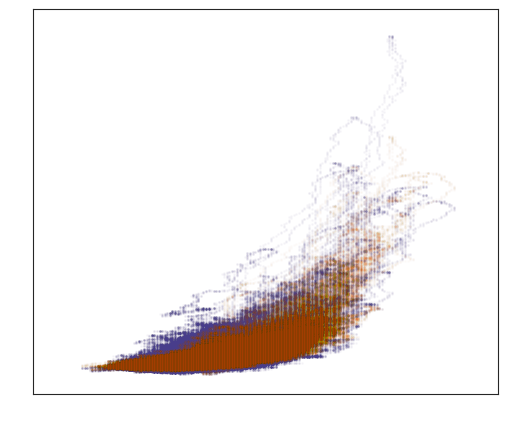

In [ ]:
#plot in linear space
plt.figure(figsize=(6, 5))

plt.scatter(sliding_300_caulo[0], caulo['gapR_wt'], marker = 'o', s = 1, c = 'darkslateblue', edgecolors = 'face', alpha = 0.03)
plt.scatter(sliding_300_caulo[0], caulo['gapR_rif'], marker = 'o', s = 1, c = 'xkcd:pumpkin', edgecolors = 'face', alpha = 0.015)

plt.ylim([-.5,4.9])
plt.xlim([10,70])
plt.gca().tick_params(axis='x', colors='white')
plt.gca().tick_params(axis='y', colors='white')
plt.savefig('./S6C_lin-notxt.png', dpi=500)
plt.show()

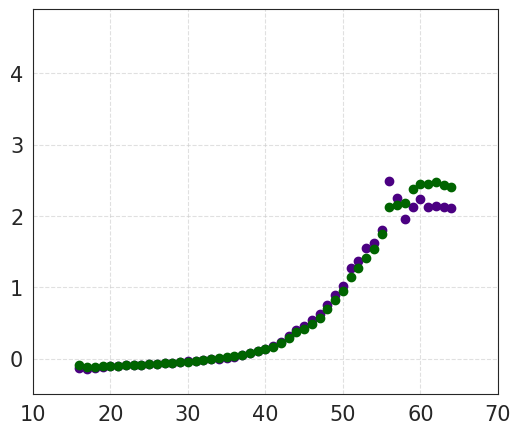

In [ ]:
#plot the exterior grid and averages for best aesthetics
plt.figure(figsize=(6, 5))

plt.scatter(range(10,90), avgapR_wt_caulo, c='indigo', marker = 'o')
plt.scatter(range(10,90), avgapR_rif_caulo, c='darkgreen', marker = 'o')

plt.ylim([-.5,4.9])
plt.xlim([10,70])
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('./S6C_lin-grid.pdf')
plt.show()

#Figure S2B: AT plot in log space

In [ ]:
# Transform rif and wt datasets into log2
log2_gapR_rif_norm = np.log2(gapR_rif_mask)
log2_gapR_wt_norm = np.log2(gapR_wt_mask)

caulo = pd.DataFrame({'gapR_rif': log2_gapR_rif_norm, 'gapR_wt': log2_gapR_wt_norm})

avgapR_rif_caulo = []
avgapR_wt_caulo = []

for i in range(10,90):
    # Filter data for the current AT content bin
    bin_indices = (sliding_300_caulo[0] >= i) & (sliding_300_caulo[0] < i+1)
    avgapR_rif_caulo.append(np.nanmean(caulo['gapR_rif'][bin_indices]))
    avgapR_wt_caulo.append(np.nanmean(caulo['gapR_wt'][bin_indices]))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipython-input-815516162.py:13: RuntimeWarning: Mean of empty slice
  avgapR_rif_caulo.append(np.nanmean(caulo['gapR_rif'][bin_indices]))
/tmp/ipython-input-815516162.py:14: RuntimeWarning: Mean of empty slice
  avgapR_wt_caulo.append(np.nanmean(caulo['gapR_wt'][bin_indices]))


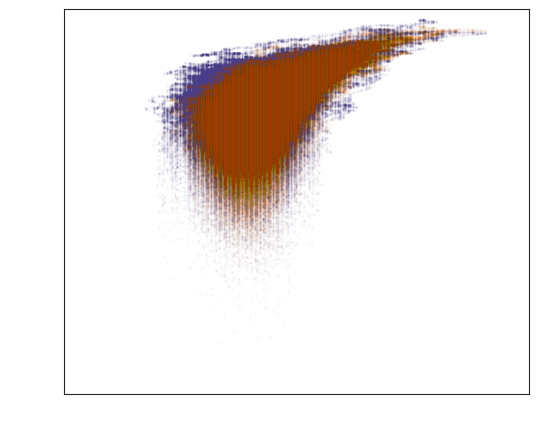

In [ ]:
#plot in logspace
plt.figure(figsize=(6, 5))

plt.scatter(sliding_300_caulo[0], caulo['gapR_wt'], marker = 'o', s = 1, c = 'darkslateblue', edgecolors = 'face', alpha = 0.03)
plt.scatter(sliding_300_caulo[0], caulo['gapR_rif'], marker = 'o', s = 1, c = 'xkcd:pumpkin', edgecolors = 'face', alpha = 0.015)

plt.ylim([-28,3])
plt.xlim([10,70])
plt.gca().tick_params(axis='x', colors='white')
plt.gca().tick_params(axis='y', colors='white')
plt.savefig('./S6C_log-notxt.png', dpi=500)
plt.show()

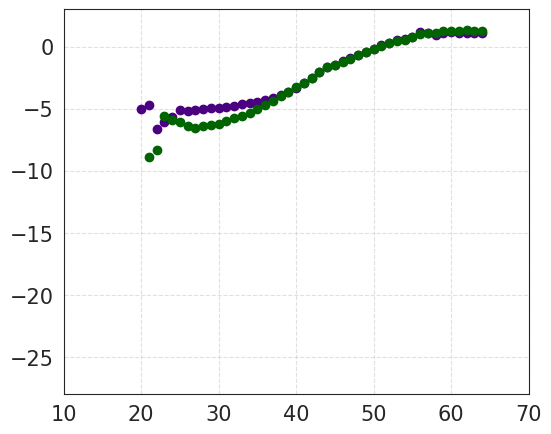

In [ ]:
#plot the exterior grid and averages for best aesthetics
plt.figure(figsize=(6, 5))

plt.scatter(range(10,90), avgapR_wt_caulo, c='indigo', marker = 'o')
plt.scatter(range(10,90), avgapR_rif_caulo, c='darkgreen', marker = 'o')

plt.ylim([-28,3])
plt.xlim([10,70])
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('./S6C_log-grid.pdf')
plt.show()

#Figure S2C: boxplots

In [ ]:
# @title GapR ChIP enrichment windows

half_window = 100

# takes chip data and cutoff value, makes a list of lists that is above the cutoff value
#output of this is chipRegions input of getSequence
def enrichedRegions(chip_data, cutoff):
    x = chip_data[chip_data > cutoff]
    out = []
    z = x.index[0]
    start = x.index[0]
    for i in range(1,len(x.index)):
        if x.index[i] == z+1:
            z = x.index[i]
        else:
            end = z
            out.append([start,end])
            z = x.index[i]
            start = x.index[i]
    out.append([start,z])
    return out

#
def getSequence(chipRegions, chip_data,genomeSequence, saveFile = False):
    chipMax = []
    sequence = []
    for i in chipRegions:
        cmax = chip_data.loc[i[0]:i[1]].idxmax()
#        print(cmax, i[0],i[1])
        chipMax.append(cmax)
        sequence.append(str(genomeSequence.seq[cmax-half_window:cmax+half_window]))
    if saveFile != False:
        a = open(saveFile, 'w')
        for i in range(len(sequence)):
            a.write('>loc{}\n'.format(chipMax[i]))
            a.write(sequence[i] + '\n')
        a.close()

    return sequence

def unenrichedRegions(chip_data, cutoff):
    x = chip_data[chip_data < cutoff]
    out = []
    z = x.index[0]
    start = x.index[0]
    for i in range(1,len(x.index)):
        if x.index[i] == z+1:
            z = x.index[i]
        else:
            end = z
            out.append([start,end])
            z = x.index[i]
            start = x.index[i]
    out.append([start,z])
    return out

def getuSequence(chipRegions, chip_data, genomeSequence, saveFile = False):
    chipMin = []
    sequence = []
    for i in chipRegions:
        if (i[1] - i[0]) > 100:
            cmin = chip_data.loc[i[0]:i[1]].idxmin()
            chipMin.append(cmin)
            sequence.append(str(genomeSequence.seq[cmin-half_window:cmin+half_window]))
    if saveFile != False:
        a = open(saveFile, 'w')
        for i in range(len(sequence)):
            a.write('>loc{}\n'.format(chipMin[i]))
            a.write(sequence[i] + '\n')
        a.close()

    return sequence

#make 100 random positions to compare enrichment windows to
random_positions = np.random.choice(len(caulobactergbk), size=100, replace=False) #without replacement
random_100 = pd.DataFrame(random_positions, columns=['position'])
display(random_100.head())

,position
0,460743
1,3164256
2,1053201
3,1708525
4,3445470


In [ ]:
#generate windows for 5% most enriched and de-enriched GapR regions

#find 5% quantile for rif and wt peaks
print(("bottom 5 percent rif (true) "),(np.quantile(gapR_rif_norm, 0.05)))
print(("top 5 percent rif "), (np.quantile(gapR_rif_norm, 0.95)))
print(("bottom 5 percent wt (true)"),(np.quantile(gapR_wt_norm, 0.05)))
print(("top 5 percent wt"), (np.quantile(gapR_wt_norm, 0.95)))

#use quantile as threshold cutoff
rif_enriched_windows_5 = enrichedRegions(gapR_rif_norm, 0.14768356894527906)
rif_nochip_windows_5 = unenrichedRegions(gapR_rif_norm, -0.09451845558257815)
wt_enriched_windows_5 = enrichedRegions(gapR_wt_norm, 0.19664495062840362)
wt_nochip_windows_5 = unenrichedRegions(gapR_wt_norm, -0.11562839831731775)

#turn into pandas dfs for more intuitive processing
rif_enriched_windows_5 = pd.DataFrame(rif_enriched_windows_5, columns=['start', 'end'])
rif_nochip_windows_5 = pd.DataFrame(rif_nochip_windows_5, columns=['start', 'end'])
wt_enriched_windows_5 = pd.DataFrame(wt_enriched_windows_5, columns=['start', 'end'])
wt_nochip_windows_5 = pd.DataFrame(wt_nochip_windows_5, columns=['start', 'end'])

#calculate the number of peaks within each dataset
print(("_" * 30))
print(" " *30)
print ("number of top 5% GapR-ChIP peaks:" , len(wt_enriched_windows_5))
print ("number of top 5% GapR-ChIP valleys:" , len(wt_nochip_windows_5))
print ("number of top 5% Rif-GapR-ChIP peaks:" , len(rif_enriched_windows_5))
print ("number of top 5% Rif-GapR-ChIP valleys:" , len(rif_nochip_windows_5))

bottom 5 percent rif (true)  -0.09451845558257815
top 5 percent rif  0.14768356894527906
bottom 5 percent wt (true) -0.11562839831731775
top 5 percent wt 0.19664495062840362
______________________________
                              
number of top 5% GapR-ChIP peaks: 692
number of top 5% GapR-ChIP valleys: 1602
number of top 5% Rif-GapR-ChIP peaks: 689
number of top 5% Rif-GapR-ChIP valleys: 1905


In [ ]:
#functions to find max ChIP of GapR enriched windows and min chip of GapR de-enriched windows

def get_max_chip_position(row, chip_data):
    start = int(row['start'])
    end = int(row['end'])
    window_data = chip_data[start:end+1]
    max_index_in_window = np.argmax(window_data)

    return start + max_index_in_window

def get_min_chip_position(row, chip_data):
    start = int(row['start'])
    end = int(row['end'])
    window_data = chip_data[start:end+1]
    min_index_in_window = np.argmin(window_data)

    return start + min_index_in_window

#find max ChIP of GapR enriched windows and min chip of GapR de-enriched windows
rif_enriched_windows_5['max_chip_rif_position'] = rif_enriched_windows_5.apply(lambda row: get_max_chip_position(row, gapR_rif_norm), axis=1)
rif_nochip_windows_5['min_chip_rif_position'] = rif_nochip_windows_5.apply(lambda row: get_min_chip_position(row, gapR_rif_norm), axis=1)
wt_enriched_windows_5['max_chip_wt_position'] = wt_enriched_windows_5.apply(lambda row: get_max_chip_position(row, gapR_wt_norm), axis=1)
wt_nochip_windows_5['min_chip_wt_position'] = wt_nochip_windows_5.apply(lambda row: get_min_chip_position(row, gapR_wt_norm), axis=1)

# Calculate AT content (from AT_content_300) at the max or min_chip position
dataframes_to_process = [
    (rif_enriched_windows_5, 'max_chip_rif_position'),
    (rif_nochip_windows_5, 'min_chip_rif_position'),
    (wt_enriched_windows_5, 'max_chip_wt_position'),
    (wt_nochip_windows_5, 'min_chip_wt_position'),
    (random_100, 'position')
]

for df, position_col in dataframes_to_process:
    df['AT_content_300'] = df[position_col].apply(lambda x: sliding_300_caulo[0][int(x)] )


Percentage: 5%
Window size: 300bp
T-test (Random vs WT enriched): Statistic=-16.5567, P-value=5.2176e-37
T-test (WT enriched vs Rif enriched): Statistic=-4.1148, P-value=4.1128e-05


/tmp/ipykernel_45795/3824664606.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Category', y='AT_content', palette='viridis', showfliers=False, order=category_order)


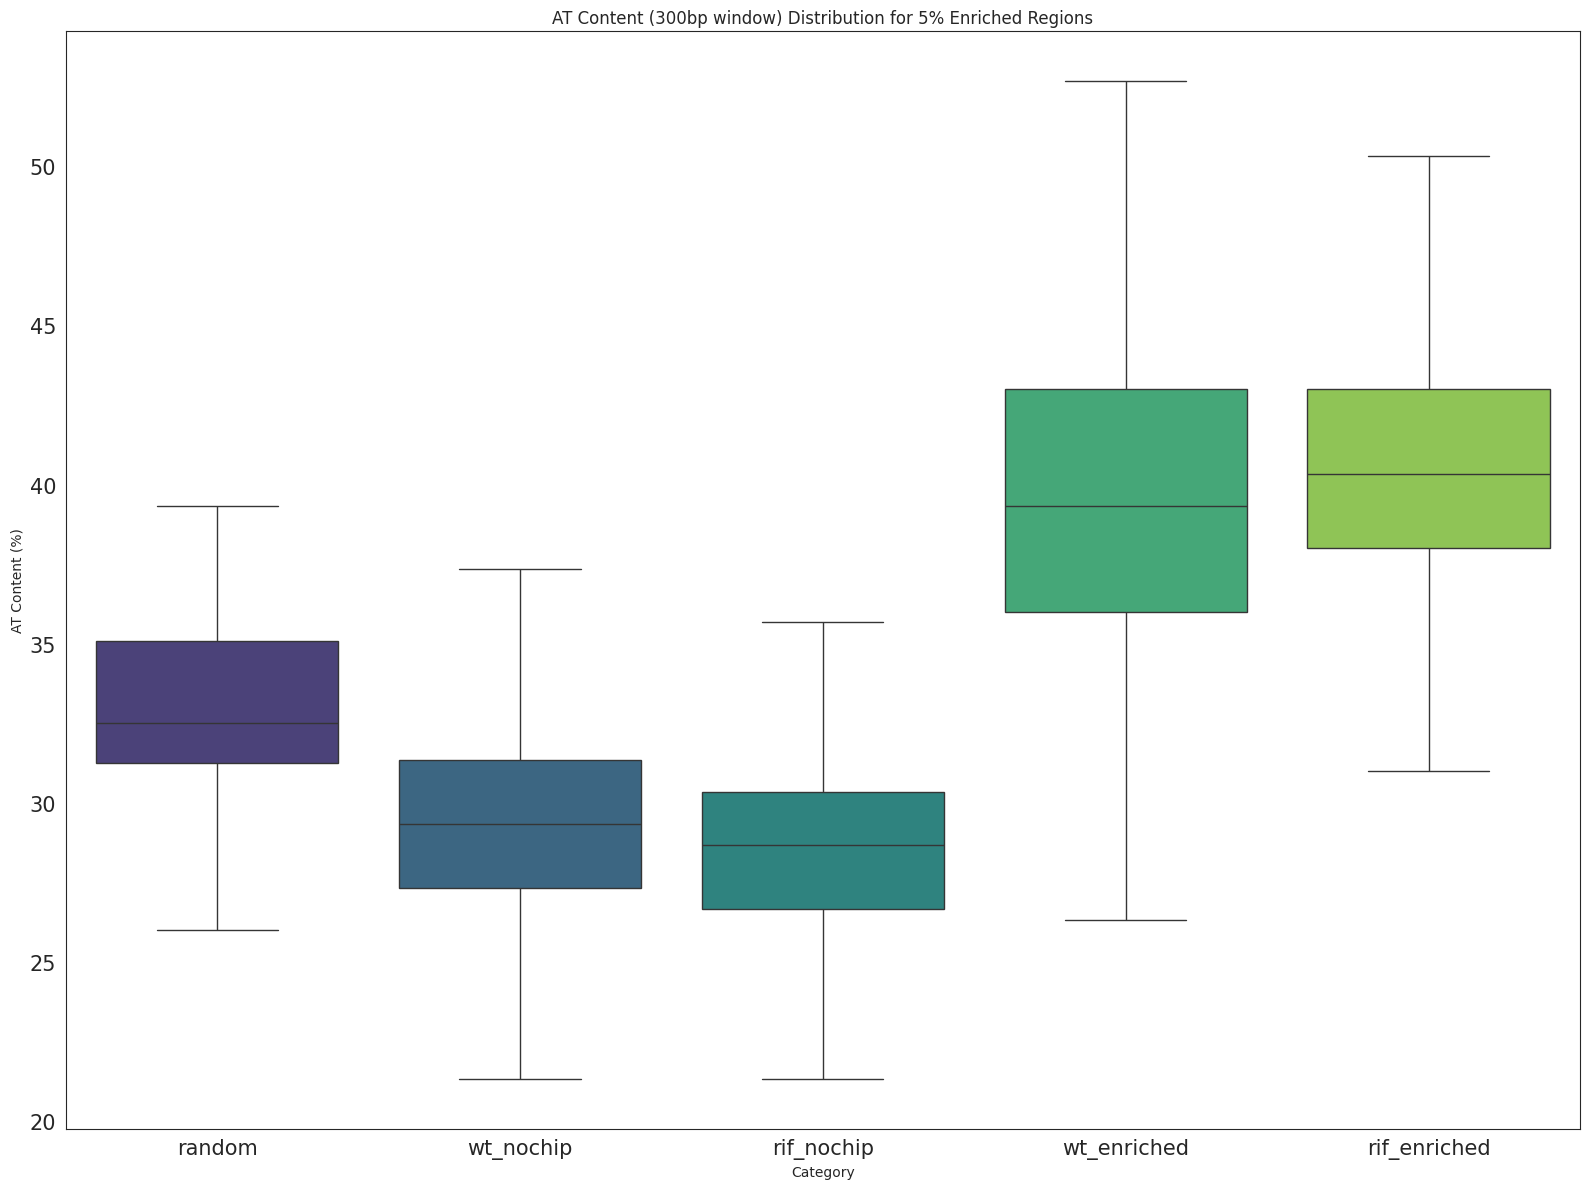

In [ ]:
#plot and run statistics

# Define the enrichment percentages to plot
percentages_to_plot = [5]
window_size = 300

for percentage in percentages_to_plot:
    plt.figure(figsize=(16, 12))

    # Get the enriched dataframes for the current percentage
    wt_enriched_df = globals().get(f'wt_enriched_windows_{percentage}')
    rif_enriched_df = globals().get(f'rif_enriched_windows_{percentage}')
    wt_nochip_df = globals().get(f'wt_nochip_windows_{percentage}')
    rif_nochip_df = globals().get(f'rif_nochip_windows_{percentage}')
    random_df = random_100 # Get the random dataframe


    plot_df = pd.DataFrame({
        'AT_content': pd.concat([
            wt_enriched_df[f'AT_content_{window_size}'],
            rif_enriched_df[f'AT_content_{window_size}'],
            wt_nochip_df[f'AT_content_{window_size}'],
            rif_nochip_df[f'AT_content_{window_size}'],
            random_df[f'AT_content_{window_size}']
        ], ignore_index=True),
        'Category': (
            ['wt_enriched'] * len(wt_enriched_df) +
            ['rif_enriched'] * len(rif_enriched_df) +
            ['wt_nochip'] * len(wt_nochip_df) +
            ['rif_nochip'] * len(rif_nochip_df) +
            ['random'] * len(random_df)
        )
    })

    # Perform t-tests and display results
    random_at_content = plot_df[plot_df['Category'] == 'random']['AT_content']
    wt_enriched_at_content = plot_df[plot_df['Category'] == 'wt_enriched']['AT_content']
    rif_enriched_at_content = plot_df[plot_df['Category'] == 'rif_enriched']['AT_content']

    ttest_random_wt_enriched = stats.ttest_ind(random_at_content, wt_enriched_at_content, equal_var=False) #doesn't assume equal size/variance ##welches t test
    ttest_wt_enriched_rif_enriched = stats.ttest_ind(wt_enriched_at_content, rif_enriched_at_content, equal_var=False) #^^

    print(f"Percentage: {percentage}%")
    print(f"Window size: {window_size}bp")
    print(f"T-test (Random vs WT enriched): Statistic={ttest_random_wt_enriched.statistic:.4f}, P-value={ttest_random_wt_enriched.pvalue:.4e}")
    print(f"T-test (WT enriched vs Rif enriched): Statistic={ttest_wt_enriched_rif_enriched.statistic:.4f}, P-value={ttest_wt_enriched_rif_enriched.pvalue:.4e}")


    category_order = ['random', 'wt_nochip', 'rif_nochip', 'wt_enriched', 'rif_enriched']  # display order
    sns.boxplot(data=plot_df, x='Category', y='AT_content', palette='viridis', showfliers=False, order=category_order)
    plt.title(f'AT Content ({window_size}bp window) Distribution for {percentage}% Enriched Regions')
    plt.xlabel('Category')
    plt.ylabel('AT Content (%)')
    plt.tight_layout()
    #plt.savefig('./S2C_boxplots.pdf')
    plt.show()

#Figure 8F: 3' pileups

In [ ]:
###loading operon file (from microbes online)
gene1=np.loadtxt('./data/gnc56.txt', delimiter='\t',dtype='str',skiprows=1,usecols=[2])
gene2=np.loadtxt('./data/gnc56.txt', delimiter='\t',dtype='str',skiprows=1,usecols=[3])
operon=np.loadtxt('./data/gnc56.txt', delimiter='\t',dtype='str',skiprows=1,usecols=[6])

In [ ]:
np.arange(0,)

array([], dtype=int64)

In [ ]:
#RNA-seq data
D356_means = pd.read_csv('./data/D16-4815-1939G_align_means', sep = '\t', index_col = None) #matched RNA-seq for the GapR-3xFLAG strain

d356_rnaseq_rpkM=np.zeros([1,len(genome.name)])

for i in range(len(genome.name)):
    j = np.where(D356_means.CCNA==genome.name[i])
    if len(j[0])>0:
        if len(j[0])>1:
            print("Warning: multiple matches:", i,"->", j[0])
            d356_rnaseq_rpkM[0][i]=float(D356_means.rpkM[j[0][-1]])
        else:
            d356_rnaseq_rpkM[0][i]=float(D356_means.rpkM[j[0][0]])

In [ ]:
###finding all the operons in the genome and loading them in 2 arrays (positive, negative strand)

mo_operons=np.zeros([1,len(genome.name)], dtype=bool)
operon_size=np.zeros([1,len(genome.name)])
start_tus=np.zeros([1,len(genome.name)],dtype=int)
j=0
while (j<2613):
    if operon[j]=="TRUE":
        k=j+1
        go= True
        while go:
            if gene2[k-1]==gene1[k]:
                if operon[k]=='TRUE':
                    k=k+1
                else: go=False
            else: go=False
        indice_j=0
        indice_k=0
        weird=False
        for i in range(0,len(genome.name)):
            if genome.name[i]==gene1[j]:
                indice_j=i
                if (i==1553) or (i==3542):
                    weird=True
            if genome.name[i]==gene2[k-1]:
                indice_k=i
        if (genome.strand[indice_j]<0) & (weird==False):
            mo_operons[0,indice_j]=True
            operon_size[0,indice_j]=genome.start[indice_k]-genome.end[indice_j]
            start_tus[0,indice_j]=genome.start[indice_k]
            if operon_size[0,indice_j]<0:
                print(indice_j)
        else:
            if indice_k>0:
                mo_operons[0,indice_k]=True
                operon_size[0,indice_k]=genome.end[indice_k]-genome.start[indice_j]
                start_tus[0,indice_k]=genome.start[indice_j]
                if operon_size[0,indice_k]<0:
                    print('k', indice_k)

        j=k

    else:
        indice_j=0
        indice_jplusone=0
        for i in range(0,len(genome.name)):
            if genome.name[i]==gene1[j]:
                indice_j=i
        if (gene1[j]!=gene2[j-1]):
            mo_operons[0, indice_j]=True
            operon_size[0,indice_j]=genome.length[indice_j]
            start_tus[0,indice_j]=genome.start[indice_j]
        if (gene1[j]==gene2[j-1])&(operon[j-1]=='FALSE'):
            mo_operons[0, indice_j]=True
            operon_size[0,indice_j]=genome.length[indice_j]
            start_tus[0,indice_j]=genome.start[indice_j]
        if (gene2[j]!=gene1[j+1]):
            for i in range(0,len(genome.name)):
                if genome.name[i]==gene2[j]:
                    indice_jplusone=i
            mo_operons[0,indice_jplusone]=True
            operon_size[0,indice_jplusone]=genome.length[indice_jplusone]
            start_tus[0,indice_jplusone]=genome.start[indice_jplusone]
        j+=1


operons_all=np.zeros([1,len(genome.name)], dtype=bool)
operon_size_all=np.zeros([1,len(genome.name)])
start_tus_1=np.zeros([1,len(genome.name)], dtype=int)
for i in range(1, len(genome.name)-1):
    if mo_operons[0,i]==True:
        operons_all[0,i]=True
        operon_size_all[0,i]=operon_size[0,i]
        start_tus_1[0,i]=start_tus[0,i]
    else:
        if (genome.strand[i]>0) & (genome.strand[i-1]<0):
            if genome.strand[i+1]<0:
                operons_all[0,i]=True
                operon_size_all[0,i]=genome.length[i]
                start_tus_1[0,i]=genome.start[i]
        if (genome.strand[i])<0 & (genome.strand[i-1]>0):
            if genome.strand[i+1]>0:
                operons_all[0,i]=True
                operon_size_all[0,i]=genome.length[i]
                start_tus_1[0,i]=genome.start[i]

print(len(operons_all[operons_all==True]))
print(len(operon_size_all[operon_size_all>1]))
###splitting +/- ends of genes
operons_all_plus=np.zeros([1,len(genome.name)], dtype=bool)
operons_all_minus=np.zeros([1,len(genome.name)], dtype=bool)
for i in range(0,len(genome.name)):
    if operons_all[0,i]==True:
        if genome.strand[i]>0:
            operons_all_plus[0,i]=True
        else:
            operons_all_minus[0,i]=True

2895
2895


In [ ]:
### Function to populate an array that contains the sliding window sum of the N previous bps

def next_N_sum(data,N):
    data_len = len(data)
    cumsum = data.astype(np.float64).cumsum()
    next_N_sum = np.zeros([1, data_len], dtype=np.float64)
    next_N_sum[0,:N] = cumsum[:N]
    next_N_sum[0,N:] = cumsum[N:] - cumsum[:data_len-N]
    return next_N_sum

In [ ]:
### function that plots histograms of the difference between the sliding window average of two signals before
## and after the ends and starts of genes
###returns histogram for the ends of genes on top and histogram for the starts at the bottom, red is chip signal from
## genes>150 rpkm, and black <50 rpkm
def sliding_window_hist_plot(chip_file_1, rnaseq, filename):
    N = 1000
    next_N_sum_file_1_rev = next_N_sum(chip_file_1[0,:],N) #do cum sum to single chip file across window size N (backwards)
    next_N_sum_file_1 = next_N_sum(chip_file_1[0,::-1],N) #do cum sum to single chip file across window size N (forwards)
    next_N_sum_file_1[0,:] = next_N_sum_file_1[0,::-1] #flip it and reverse it

    #avg across windows
    next_N_sum_avg = next_N_sum_file_1/N
    next_N_sum_avg_rev = next_N_sum_file_1_rev/N

    #plus sign genes:

    #load locations: starts and ends and RNA seq info
    ends = np.array(genome.end)[operons_all_plus[0,:]]
    starts = np.array(start_tus_1)[0,operons_all_plus[0,:]]
    data_x = rnaseq[0,operons_all_plus[0,:]]
    #set thresholds
    thrsh_x = 150
    thrsh_x_2 = 50
    #do window subtraction
    data_y_end = next_N_sum_avg[0,ends[data_x>thrsh_x]]-next_N_sum_avg_rev[0,ends[data_x>thrsh_x]]
    data_y_2_end = next_N_sum_avg[0,ends[data_x<thrsh_x_2]]-next_N_sum_avg_rev[0,ends[data_x<thrsh_x_2]]
    data_y_start = next_N_sum_avg[0,starts[data_x>thrsh_x]]-next_N_sum_avg_rev[0,starts[data_x>thrsh_x]]
    data_y_2_start = next_N_sum_avg[0,starts[data_x<thrsh_x_2]]-next_N_sum_avg_rev[0,starts[data_x<thrsh_x_2]]
    #stitch together for easy plotting
    data_y_plus_end=data_y_end
    data_y_plus_end_2=data_y_2_end
    data_y_plus_start=data_y_start
    data_y_plus_start_2=data_y_2_start

    #minus sign genes

    #load locations: starts and ends and RNA seq data: automatically uses thresholds from earlier
    ends = np.array(genome.end)[operons_all_minus[0,:]]
    starts = np.array(start_tus_1)[0,operons_all_minus[0,:]]
    data_x = d356_rnaseq_rpkM[0,operons_all_minus[0,:]]
    #do window subtraction
    data_y_end = next_N_sum_avg_rev[0,ends[data_x>thrsh_x]]-next_N_sum_avg[0,ends[data_x>thrsh_x]]
    data_y_2_end = next_N_sum_avg_rev[0,ends[data_x<thrsh_x_2]]-next_N_sum_avg[0,ends[data_x<thrsh_x_2]]
    data_y_start = next_N_sum_avg_rev[0,starts[data_x>thrsh_x]]-next_N_sum_avg[0,starts[data_x>thrsh_x]]
    data_y_2_start = next_N_sum_avg_rev[0,starts[data_x<thrsh_x_2]]-next_N_sum_avg[0,starts[data_x<thrsh_x_2]]
    #stitch together for easy plotting
    data_y_rev_end=data_y_end
    data_y_rev_end_2=data_y_2_end
    data_y_rev_start=data_y_start
    data_y_rev_start_2=data_y_2_start

    #Concatenate + and - strands array
    data_y_concat_end=np.concatenate((data_y_plus_end,data_y_rev_end))
    data_y_concat_2_end=np.concatenate((data_y_plus_end_2,data_y_rev_end_2))
    data_y_concat_start=np.concatenate((data_y_plus_start,data_y_rev_start))
    data_y_concat_2_start=np.concatenate((data_y_plus_start_2,data_y_rev_start_2))

    #plot end of genes
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5,4))

    bins = np.arange(-0.35,0.36,0.02)
    bins[0] = -0.5
    bins[-1] = 0.5
    h = np.histogram(data_y_concat_end, bins=bins)
    ho = np.histogram(data_y_concat_2_end,bins=bins)

    axes.bar(ho[1][:-1], ho[0]/float(len(data_y_concat_2_end)), np.diff(ho[1]),color='k',alpha=0.5 ,align='edge' )
    axes.bar(h[1][:-1], h[0]/float(len(data_y_concat_end)), np.diff(h[1]),color='r',alpha=0.5, align='edge')

    plt.xlim([-0.36,0.36])
    plt.ylim([0,0.175])
    plt.savefig(filename +'3ends.pdf')

    #plot start of genes
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5,4))

    #print bins
    h = np.histogram(data_y_concat_start, bins=bins)
    ho = np.histogram(data_y_concat_2_start,bins=bins)

    axes.bar(ho[1][:-1], ho[0]/float(len(data_y_concat_2_start)), np.diff(ho[1]),color='k',alpha=0.5 , align='edge')
    axes.bar(h[1][:-1], h[0]/float(len(data_y_concat_start)), np.diff(h[1]),color='r',alpha=0.5, align='edge')

    plt.xlim([-0.36,0.36])
    plt.ylim([0,0.175])
    plt.savefig(filename+'start.pdf')

    print('t-test of end of TUs: '+ str(stats.ttest_ind(data_y_concat_end,data_y_concat_2_end, equal_var=False)))
    print('t-test of start of TUs: '+ str(stats.ttest_ind(data_y_concat_start,data_y_concat_2_start, equal_var=False)))
    print('number of genes above high threshold: '+str(len(data_y_concat_start)))
    print('number of genes below low threshold: '+str(len(data_y_concat_2_start)))


t-test of end of TUs: TtestResult(statistic=np.float64(5.5783582681579995), pvalue=np.float64(2.876921412287423e-08), df=np.float64(1497.0363032996502))
t-test of start of TUs: TtestResult(statistic=np.float64(1.0395395830030891), pvalue=np.float64(0.298718708363357), df=np.float64(1524.4015312283775))
number of genes above high threshold: 748
number of genes below low threshold: 1280


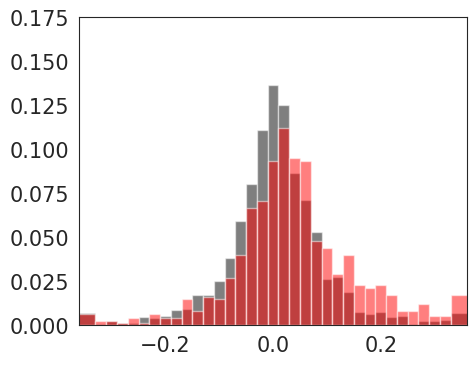

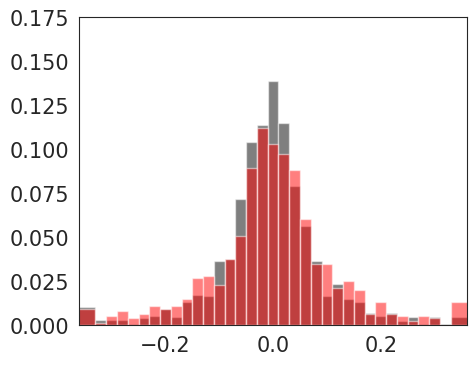

In [ ]:
sliding_window_hist_plot(chip_356, d356_rnaseq_rpkM, './data/chipwt_LK1')

t-test of end of TUs: TtestResult(statistic=np.float64(-2.1284856881843233), pvalue=np.float64(0.03344625318598041), df=np.float64(1632.1241089580708))
t-test of start of TUs: TtestResult(statistic=np.float64(0.6094999265161343), pvalue=np.float64(0.5422811175444251), df=np.float64(1573.50219420759))
number of genes above high threshold: 748
number of genes below low threshold: 1280


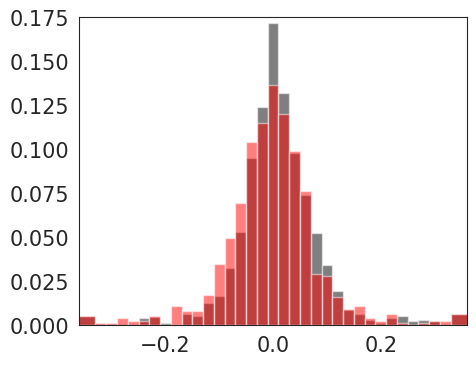

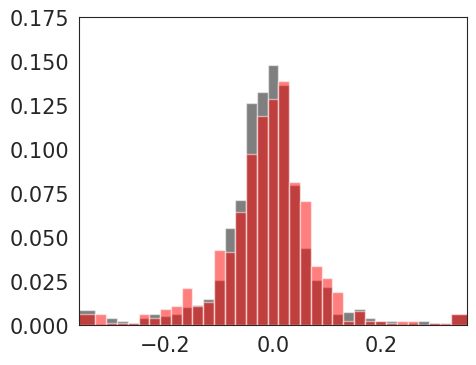

In [ ]:
sliding_window_hist_plot(chip_rif, d356_rnaseq_rpkM, './data/chiprif_LK1')

#Figure 8G: pie charts

In [ ]:
#define all intergenic regions
intergenic = []
# adding the first intergenic region from 0 to first gene
intergenic.append([0,int(D356_means.start[0])])

#go through the gene annotation to extract all intergenic regions
for i in range(1,len(D356_means)-1):
    intergenic.append([int(D356_means.end[i]),int(D356_means.start[i+1])])
intergenic.append([int(D356_means.end[i+1]),len(caulobacterfasta.seq)])

In [ ]:
#assign convergent vs divergent vs same direction for all genes
direction_int = []
threshold = 0.1 #below this threshold is called no transcription
#for (almost) every intergenic region.. except first and last
for i in intergenic[2:-1]: #
    #measure txnal activity
    txn_avg = np.mean(W356_RNAfor_df.value[i[0]-5000:i[1]+5000].values+W356_RNArev_df.value[i[0]-5000:i[1]+5000].values)
    mid = int(round(np.mean(i),0))
    #if there is low transcription, record that
    if txn_avg < threshold:
        direction_int.append('no transcription')
    #if there is txn, look at the 2kb upstream and downstream
    if txn_avg >= threshold:
        left_f = np.mean(W356_RNAfor_df.value[i[0]-2000:mid].values)
        left_r = np.mean(W356_RNArev_df.value[i[0]-2000:mid].values)
        right_f = np.mean(W356_RNAfor_df.value[mid:i[1]+2000].values)
        right_r = np.mean(W356_RNArev_df.value[mid:i[1]+2000].values)
        #if there is txnal activity left or right, lengthen that and collect the mean
        if (left_f < threshold) and (left_r < threshold):
            left_f = np.mean(W356_RNAfor_df.value[i[0]-5000:mid].values)
            left_r = np.mean(W356_RNArev_df.value[i[0]-5000:mid].values)
        if (right_f < threshold) and (right_r < threshold):
            right_f = np.mean(W356_RNAfor_df.value[mid:i[1]+5000].values)
            right_r = np.mean(W356_RNArev_df.value[mid:i[1]+5000].values)
#        print(round(left_f,4),round(left_r,4),' R',round(right_f,4),round(right_r,4),i)

        #then see if there is txnal activity left of gene or right of gene, and record if it is inline , convergenr or divergent
        if ((left_f < threshold) and (left_r < threshold)) or ((right_f < threshold) and (right_r < threshold)):
            direction_int.append('same direction')
        elif left_f > left_r:
            if right_r > right_f:
                direction_int.append('convergent')
            else:
                direction_int.append('same direction')
        elif left_f <= left_r:
            if right_r > right_f:
                direction_int.append('same direction')
            else:
                direction_int.append('divergent')


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
#measuring the TU land
convergent_count = direction_int.count('convergent')
divergent_count = direction_int.count('divergent')
same_direction_count = direction_int.count('same direction')
no_transcription_count = direction_int.count('no transcription')
total_count = len(direction_int)


print(f"threshold: {threshold}")
print(f"Convergent regions: {convergent_count}")
print(f"Divergent regions: {divergent_count}")
print(f"Same direction regions: {same_direction_count}")
print(f"No transcription regions: {no_transcription_count}")
print(f"Total regions: {total_count}")

threshold: 0.1
Convergent regions: 109
Divergent regions: 112
Same direction regions: 1326
No transcription regions: 382
Total regions: 1929


In [ ]:
#from GapR peaks (wild-type ChIP 5%) assign direction for each peak
direction_u = []
threshold = 0.1

for i in wt_enriched_windows_5.itertuples():
    txn_avg = np.mean(W356_RNAfor_df.value[i.start-5000:i.end+5000].values+W356_RNArev_df.value[i.start-5000:i.end+5000].values)
    mid = int(round(np.mean([i.start, i.end]),0))
    if txn_avg < threshold:
        direction_u.append('no transcription')
    if txn_avg >= threshold:
        left_f = np.mean(W356_RNAfor_df.value[i.start-2000:mid].values)
        left_r = np.mean(W356_RNArev_df.value[i.start-2000:mid].values)
        right_f = np.mean(W356_RNAfor_df.value[mid:i.end+2000].values)
        right_r = np.mean(W356_RNArev_df.value[mid:i.end+2000].values)
        if (left_f < threshold) and (left_r < threshold):
            left_f = np.mean(W356_RNAfor_df.value[i.start-5000:mid].values)
            left_r = np.mean(W356_RNArev_df.value[i.start-5000:mid].values)
        if (right_f < threshold) and (right_r < threshold):
            right_f = np.mean(W356_RNAfor_df.value[mid:i.end+5000].values)
            right_r = np.mean(W356_RNArev_df.value[mid:i.end+5000].values)
#        print(round(left_f,4),round(left_r,4),' R',round(right_f,4),round(right_r,4),i)
        if ((left_f < threshold) and (left_r < threshold)) or ((right_f < threshold) and (right_r < threshold)):
            direction_u.append('same direction')
        elif left_f > left_r:
            if right_r > right_f:
                direction_u.append('convergent')
            else:
                direction_u.append('same direction')
        elif left_f <= left_r:
            if right_r > right_f:
                direction_u.append('same direction')
            else:
                direction_u.append('divergent')

In [ ]:
convergent_count = direction_u.count('convergent')
divergent_count = direction_u.count('divergent')
same_direction_count = direction_u.count('same direction')
no_transcription_count = direction_u.count('no transcription')
total_count = len(direction_u)


print(f"threshold: {threshold}")
print(f"Convergent regions: {convergent_count}")
print(f"Divergent regions: {divergent_count}")
print(f"Same direction regions: {same_direction_count}")
print(f"No transcription regions: {no_transcription_count}")
print(f"Total regions: {total_count}")

threshold: 0.1
Convergent regions: 145
Divergent regions: 51
Same direction regions: 397
No transcription regions: 99
Total regions: 692


In [ ]:
#From Rif peaks (rif ChIP 5%)
direction_r = []
threshold = 0.1

for i in rif_enriched_windows_5.itertuples():
    txn_avg = np.mean(W356_RNAfor_df.value[i.start-5000:i.end+5000].values+W356_RNArev_df.value[i.start-5000:i.end+5000].values)
    mid = int(round(np.mean([i.start, i.end]),0))
    if txn_avg < threshold:
        direction_r.append('no transcription')
    if txn_avg >= threshold:
        left_f = np.mean(W356_RNAfor_df.value[i.start-2000:mid].values)
        left_r = np.mean(W356_RNArev_df.value[i.start-2000:mid].values)
        right_f = np.mean(W356_RNAfor_df.value[mid:i.end+2000].values)
        right_r = np.mean(W356_RNArev_df.value[mid:i.end+2000].values)
        if (left_f < threshold) and (left_r < threshold):
            left_f = np.mean(W356_RNAfor_df.value[i.start-5000:mid].values)
            left_r = np.mean(W356_RNArev_df.value[i.start-5000:mid].values)
        if (right_f < threshold) and (right_r < threshold):
            right_f = np.mean(W356_RNAfor_df.value[mid:i.end+5000].values)
            right_r = np.mean(W356_RNArev_df.value[mid:i.end+5000].values)
#        print(round(left_f,4),round(left_r,4),' R',round(right_f,4),round(right_r,4),i)
        if ((left_f < threshold) and (left_r < threshold)) or ((right_f < threshold) and (right_r < threshold)):
            direction_r.append('same direction')
        elif left_f > left_r:
            if right_r > right_f:
                direction_r.append('convergent')
            else:
                direction_r.append('same direction')
        elif left_f <= left_r:
            if right_r > right_f:
                direction_r.append('same direction')
            else:
                direction_r.append('divergent')

In [ ]:
convergent_count = direction_r.count('convergent')
divergent_count = direction_r.count('divergent')
same_direction_count = direction_r.count('same direction')
no_transcription_count = direction_r.count('no transcription')
total_count = len(direction_r)


print(f"threshold: {threshold}")
print(f"Convergent regions: {convergent_count}")
print(f"Divergent regions: {divergent_count}")
print(f"Same direction regions: {same_direction_count}")
print(f"No transcription regions: {no_transcription_count}")
print(f"Total regions: {total_count}")

threshold: 0.1
Convergent regions: 44
Divergent regions: 76
Same direction regions: 479
No transcription regions: 86
Total regions: 685


In [ ]:
# Perform Fisher's exact tests for different gene orientations, using hardcoded numbers.

# Perform Fisher's exact test for Convergent regions
convergent_table = [[44, 641],  # Rif Enriched: Convergent (44), Non-Convergent (685 - 44 = 641)
                   [145, 547]] # WT Enriched: Convergent (145), Non-Convergent (692 - 145 = 547)

odds_ratio_convergent, p_value_convergent = stats.fisher_exact(convergent_table)

print("Fisher's Exact Test (Convergent Regions):")
print(f"Contingency Table:\n{np.array(convergent_table)}")
print(f"Odds Ratio: {odds_ratio_convergent:.4f}")
print(f"P-value: {p_value_convergent:.4e}")
print("-" * 30)

# Perform Fisher's exact test for Divergent regions
divergent_table = [[76, 609], # Rif Enriched: Divergent (76), Non-Divergent (685 - 76 = 609)
                   [51, 641]] # WT Enriched: Divergent (51), Non-Divergent (692 - 51 = 641)

odds_ratio_divergent, p_value_divergent = stats.fisher_exact(divergent_table)

print("Fisher's Exact Test (Divergent Regions):")
print(f"Contingency Table:\n{np.array(divergent_table)}")
print(f"Odds Ratio: {odds_ratio_divergent:.4f}")
print(f"P-value: {p_value_divergent:.4e}")
print("-" * 30)

# Perform Fisher's exact test for Same Direction regions
inline_table = [[479, 206], # Rif Enriched: Same Direction (479), Non-Same Direction (685 - 479 = 206)
                [397, 295]] # WT Enriched: Same Direction (397), Non-Same Direction (692 - 397 = 295)

odds_ratio_inline, p_value_inline = stats.fisher_exact(inline_table)

print("Fisher's Exact Test (Same Direction Regions):")
print(f"Contingency Table:\n{np.array(inline_table)}")
print(f"Odds Ratio: {odds_ratio_inline:.4f}")
print(f"P-value: {p_value_inline:.4e}")
print("-" * 30)

# Perform Fisher's exact test for No Transcription regions
silent_table = [[86, 599], # Rif Enriched: No Transcription (86), Transcription (685 - 86 = 599)
                [99, 593]] # WT Enriched: No Transcription (99), Transcription (692 - 99 = 593)

odds_ratio_silent, p_value_silent = stats.fisher_exact(silent_table)

print("Fisher's Exact Test (No Transcription Regions):")
print(f"Contingency Table:\n{np.array(silent_table)}")
print(f"Odds Ratio: {odds_ratio_silent:.4f}")
print(f"P-value: {p_value_silent:.4e}")

Fisher's Exact Test (Convergent Regions):
Contingency Table:
[[ 44 641]
 [145 547]]
Odds Ratio: 0.2589
P-value: 1.4065e-15
------------------------------
Fisher's Exact Test (Divergent Regions):
Contingency Table:
[[ 76 609]
 [ 51 641]]
Odds Ratio: 1.5685
P-value: 1.9663e-02
------------------------------
Fisher's Exact Test (Same Direction Regions):
Contingency Table:
[[479 206]
 [397 295]]
Odds Ratio: 1.7278
P-value: 1.4093e-06
------------------------------
Fisher's Exact Test (No Transcription Regions):
Contingency Table:
[[ 86 599]
 [ 99 593]]
Odds Ratio: 0.8600
P-value: 3.4435e-01
